In [56]:
# Asegura que las dependencias estén instaladas.
try:
    import matplotlib.pyplot as plt
except Exception:
    import sys, subprocess
    print('matplotlib no encontrado — instalando...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib'])
    import matplotlib.pyplot as plt

print('matplotlib disponible:', hasattr(plt, 'plot'))


matplotlib disponible: True


In [57]:
# Requisitos básicos
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print('TensorFlow / Keras:', keras.__version__)

TensorFlow / Keras: 3.10.0


In [58]:
# Mount Drive files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# Ajusta este path según dónde tengas los ficheros. En Colab monta Drive y pon DATA_DIR='/content/drive/MyDrive/...'
DATA_DIR = os.path.join('data','trees')  # default para Colab
if not os.path.isdir(DATA_DIR) and os.path.isdir('/content/drive/MyDrive/Colab Notebooks/TIA_Lab3/data/trees/'):
    DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/TIA_Lab3/data/trees/'
print('Usando DATA_DIR =', DATA_DIR)
print('Ficheros disponibles:', [f for f in os.listdir(DATA_DIR) if f.endswith('.txt')])

Usando DATA_DIR = /content/drive/MyDrive/Colab Notebooks/TIA_Lab3/data/trees/
Ficheros disponibles: ['dev.txt', 'train.txt', 'test.txt']


In [60]:
# Parser sencillo para las líneas del dataset (formato tipo Stanford Sentiment Treebank en árboles entre paréntesis).
# Se extrae etiqueta del root y los tokens de la frase.
def parse_tree_line(line, easy_label_map={0:0, 1:0, 2:None, 3:1, 4:1}):
    """Devuelve (sentence, mapped_label).
    Se aplica el mapeo `easy_label_map` que convierte las etiquetas 0/1->0 (negativo), 3/4->1 (positivo)
    y mapea 2 a None (neutro) que se ignorará en la carga.
    """
    line = line.strip()
    m = re.match(r'^\((\d+)\s', line)
    if not m:
        raw_label = 0
    else:
        raw_label = int(m.group(1))
    # extraer tokens en palabras alfanuméricas/contracciones simples
    tokens = re.findall(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?", line)
    # eliminar etiqueta numerica
    if tokens and tokens[0].isdigit():
        tokens = tokens[1:]
    sentence = ' '.join(tokens)
    mapped = easy_label_map.get(raw_label, None)
    return sentence, mapped


In [61]:
# Cargar datasets completos (train/dev/test) en listas (sentences, labels)
def load_split(fname):
    sents = []
    labs = []
    path = os.path.join(DATA_DIR, fname)
    with open(path, 'r', encoding='utf8') as f:
        for line in f:
            line=line.strip()
            if not line:
                continue
            sent, lab = parse_tree_line(line)
            # Ignorar ejemplos neutrales para clasificación binaria
            if lab is None:
                continue
            sents.append(sent)
            labs.append(lab)
    return sents, np.array(labs, dtype=np.int32)

train_sents, train_labels = load_split('train.txt')
dev_sents, dev_labels = load_split('dev.txt')
test_sents, test_labels = load_split('test.txt')

print('Tamaño sets: train', len(train_sents), 'dev', len(dev_sents), 'test', len(test_sents))
print('Ejemplo sentencia:', train_sents[0], '->', train_labels[0])


Tamaño sets: train 6920 dev 872 test 1821
Ejemplo sentencia: 2 2 The 2 Rock 4 3 2 is 4 2 destined 2 2 2 2 2 to 2 2 be 2 2 the 2 2 21st 2 2 2 Century 2 s 2 3 new 2 2 2 Conan 2 2 and 3 2 that 3 2 he 3 2 s 3 2 going 3 2 to 4 3 2 make 3 3 2 a 3 splash 2 2 even 3 greater 2 2 than 2 2 2 2 1 2 Arnold 2 Schwarzenegger 2 2 2 Jean Claud 2 2 Van 2 Damme 2 or 2 2 Steven 2 Segal 2 -> 1


In [62]:
# Tokenización y padding
MAX_VOCAB = 20000
MAX_LEN = 60
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_sents + dev_sents)

def to_padded(seqs, maxlen=MAX_LEN):
    seq = tokenizer.texts_to_sequences(seqs)
    return pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')

X_train = to_padded(train_sents)
X_dev = to_padded(dev_sents)
X_test = to_padded(test_sents)
y_train = train_labels
y_dev = dev_labels
y_test = test_labels

print('Shape X_train', X_train.shape, 'y_train', y_train.shape)
print('Vocab size (tokenizer):', min(MAX_VOCAB, len(tokenizer.word_index)+1))

Shape X_train (6920, 60) y_train (6920,)
Vocab size (tokenizer): 14631


In [63]:
# Función para construir un MLP/Classifier con hiperparámetros
# Clasificacion binaria (sigmoid + binary_crossentropy)
def build_mlp(vocab_size, embedding_dim=50, hidden_units=64, dropout_rate=0.5, l1_reg=0.0, l2_reg=0.0, learning_rate=1e-3):
    inputs = keras.Input(shape=(MAX_LEN,), dtype='int32')
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=False)(inputs)
    x = layers.GlobalAveragePooling1D()(x)
    # configurar regularizadores (L1, L2 o ambos)
    reg = None
    if l1_reg>0 and l2_reg>0:
        reg = regularizers.l1_l2(l1=l1_reg, l2=l2_reg)
    elif l1_reg>0:
        reg = regularizers.l1(l1_reg)
    elif l2_reg>0:
        reg = regularizers.l2(l2_reg)
    x = layers.Dense(hidden_units, activation='relu', kernel_regularizer=reg)(x)
    if dropout_rate>0:
        x = layers.Dropout(dropout_rate)(x)
    # Salida binaria
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs)
    opt = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Probar construcción
vocab_size = min(MAX_VOCAB, len(tokenizer.word_index)+1)
m = build_mlp(vocab_size)
m.summary()


Model: "functional_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_65 (InputLayer)     │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_65 (Embedding)        │ (None, 60, 50)         │       731,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_65     │ (None, 50)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 734,879 (2.80 MB)

 Trainable params: 734,879 (2.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8


109/109 - 4s - 39ms/step - accuracy: 0.8431 - loss: 0.4795 - val_accuracy: 0.8888 - val_loss: 0.3127
Epoch 2/8


109/109 - 1s - 13ms/step - accuracy: 0.8923 - loss: 0.2991 - val_accuracy: 0.8842 - val_loss: 0.3064
Epoch 3/8


109/109 - 1s - 10ms/step - accuracy: 0.8973 - loss: 0.2809 - val_accuracy: 0.8922 - val_loss: 0.3043
Epoch 4/8


109/109 - 1s - 10ms/step - accuracy: 0.9013 - loss: 0.2693 - val_accuracy: 0.8968 - val_loss: 0.2976
Epoch 5/8
109/109 - 1s - 9ms/step - accuracy: 0.9084 - loss: 0.2568 - val_accuracy: 0.8922 - val_loss: 0.3012
Epoch 6/8


109/109 - 1s - 12ms/step - accuracy: 0.9114 - loss: 0.2471 - val_accuracy: 0.8968 - val_loss: 0.2928
Epoch 7/8
109/109 - 1s - 9ms/step - accuracy: 0.9175 - loss: 0.2342 - val_accuracy: 0.8933 - val_loss: 0.3024
Epoch 8/8
109/109 - 1s - 9ms/step - accuracy: 0.9241 - loss: 0.2180 - val_accuracy: 0.8933 - val_loss: 0.3058


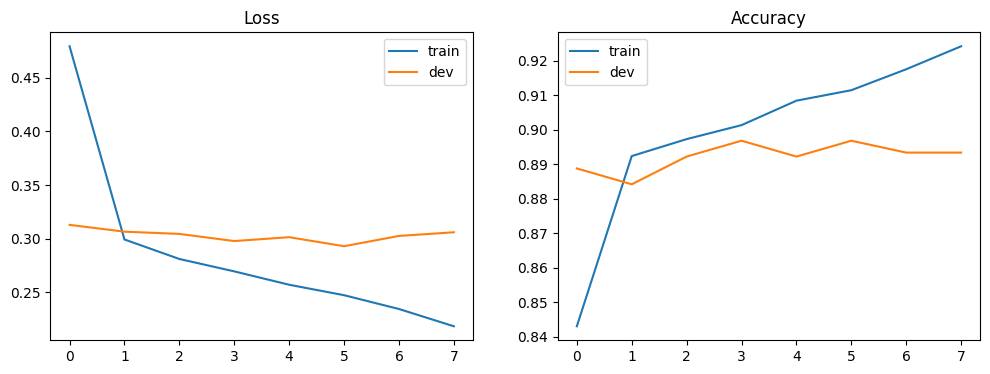

28/28 - 0s - 3ms/step - accuracy: 0.8968 - loss: 0.2928
Eval dev: [0.2928030788898468, 0.896789014339447]


In [64]:
# Función para entrenar y devolver historial, además de graficar curvas de pérdida y precisión
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
def train_and_plot(model, X_tr, y_tr, X_val, y_val, epochs=100, batch_size=32, use_callbacks=True, ckpt_path='best_model.h5'):
    callbacks = []
    if use_callbacks:
        callbacks = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
                     ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True)]
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=2, callbacks=callbacks)
    # Plot loss y accuracy
    fig, axs = plt.subplots(1,2,figsize=(12,4))
    axs[0].plot(history.history['loss'], label='train')
    axs[0].plot(history.history['val_loss'], label='dev')
    axs[0].set_title('Loss')
    axs[0].legend()
    axs[1].plot(history.history['accuracy'], label='train')
    axs[1].plot(history.history['val_accuracy'], label='dev')
    axs[1].set_title('Accuracy')
    axs[1].legend()
    plt.show()
    return history

# Ejemplo rápido: entrenar un modelo pequeño por pocas épocas (usa callbacks para early stopping y guardar el mejor modelo)
model = build_mlp(vocab_size, embedding_dim=50, hidden_units=64, dropout_rate=0.3, l2_reg=1e-4, learning_rate=1e-3)
hist = train_and_plot(model, X_train, y_train, X_dev, y_dev, epochs=8, batch_size=64, use_callbacks=True, ckpt_path='example_best_model.h5')

# Evaluar en dev
print(f'Eval dev: {model.evaluate(X_dev, y_dev, verbose=2)}')

## Búsqueda hiperparámetros

In [65]:
# Grid pequeño de ejemplo (reduce combinaciones si coste computacional alto)
from itertools import product
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
search_space = {
    'embedding_dim': [50, 100],
    'hidden_units': [16, 32, 64, 128],
    'dropout_rate': [0.2, 0.3, 0.4, 0.5],
    'l2_reg': [0.0, 1e-4],
    'learning_rate':[1e-6, 1e-5, 5e-5, 5e-4]
}
combs = list(product(search_space['embedding_dim'], search_space['hidden_units'], search_space['dropout_rate'], search_space['l2_reg'], search_space['learning_rate']))
print('Combinaciones totales (prueba):', len(combs))
results = []
# Para no ejecutar todo automáticamente
max_trials = 10 # limitado, solo esta hecho para probar
for i, (ed, hu, dr, l2v, lr) in enumerate(combs[:max_trials]):
    print(f'Trial {i+1}: embedding={ed} hidden={hu} dropout={dr} l2={l2v} lr={lr}')
    m = build_mlp(vocab_size, embedding_dim=ed, hidden_units=hu, dropout_rate=dr, l2_reg=l2v, learning_rate=lr)
    # Usar EarlyStopping por si empieza a empeorar
    cb = [EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    h = m.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=6, batch_size=64, verbose=0, callbacks=cb)
    dev_loss = h.history['val_loss'][-1]
    dev_acc = h.history['val_accuracy'][-1]
    print(f'dev_loss {dev_loss:.4f} dev_acc {dev_acc:.4f}')
    results.append({'embedding_dim':ed,'hidden_units':hu,'dropout':dr,'l2':l2v,'lr':lr,'dev_loss':dev_loss,'dev_acc':dev_acc})

# Mostrar mejores por val_loss
results_sorted = sorted(results, key=lambda x: x['dev_loss'])
for r in results_sorted[:5]:
    print(r)

Combinaciones totales (prueba): 128
Trial 1: embedding=50 hidden=16 dropout=0.2 l2=0.0 lr=1e-05
dev_loss 0.6759 dev_acc 0.8532
Trial 2: embedding=50 hidden=16 dropout=0.2 l2=0.0 lr=5e-05
dev_loss 0.5255 dev_acc 0.8796
Trial 3: embedding=50 hidden=16 dropout=0.2 l2=0.0001 lr=1e-05
dev_loss 0.6704 dev_acc 0.8624
Trial 4: embedding=50 hidden=16 dropout=0.2 l2=0.0001 lr=5e-05
dev_loss 0.5462 dev_acc 0.8670
Trial 5: embedding=50 hidden=16 dropout=0.3 l2=0.0 lr=1e-05
dev_loss 0.6785 dev_acc 0.8475
Trial 6: embedding=50 hidden=16 dropout=0.3 l2=0.0 lr=5e-05
dev_loss 0.5611 dev_acc 0.8773
Trial 7: embedding=50 hidden=16 dropout=0.3 l2=0.0001 lr=1e-05
dev_loss 0.6707 dev_acc 0.7179
Trial 8: embedding=50 hidden=16 dropout=0.3 l2=0.0001 lr=5e-05
dev_loss 0.5477 dev_acc 0.8716
Trial 9: embedding=50 hidden=16 dropout=0.4 l2=0.0 lr=1e-05
dev_loss 0.6760 dev_acc 0.6330
Trial 10: embedding=50 hidden=16 dropout=0.4 l2=0.0 lr=5e-05
dev_loss 0.5679 dev_acc 0.8349
{'embedding_dim': 50, 'hidden_units': 16,

## Selección final y evaluación en `test.txt`


Usando configuración final: {'embedding_dim': 50, 'hidden_units': 16, 'dropout': 0.2, 'l2': 0.0, 'lr': 5e-05, 'dev_loss': 0.5255140066146851, 'dev_acc': 0.8795871734619141}
Epoch 1/100


109/109 - 3s - 26ms/step - accuracy: 0.6844 - loss: 0.6884 - val_accuracy: 0.8383 - val_loss: 0.6811
Epoch 2/100


109/109 - 1s - 11ms/step - accuracy: 0.7990 - loss: 0.6722 - val_accuracy: 0.8085 - val_loss: 0.6579
Epoch 3/100


109/109 - 1s - 12ms/step - accuracy: 0.8257 - loss: 0.6469 - val_accuracy: 0.8429 - val_loss: 0.6297
Epoch 4/100


109/109 - 2s - 16ms/step - accuracy: 0.8468 - loss: 0.6197 - val_accuracy: 0.8739 - val_loss: 0.5966
Epoch 5/100


...

109/109 - 1s - 10ms/step - accuracy: 0.9092 - loss: 0.2468 - val_accuracy: 0.8956 - val_loss: 0.2916
Epoch 92/100
109/109 - 2s - 15ms/step - accuracy: 0.9104 - loss: 0.2497 - val_accuracy: 0.8945 - val_loss: 0.2917
Epoch 93/100


109/109 - 3s - 23ms/step - accuracy: 0.9117 - loss: 0.2475 - val_accuracy: 0.8945 - val_loss: 0.2913
Epoch 94/100


109/109 - 1s - 9ms/step - accuracy: 0.9085 - loss: 0.2453 - val_accuracy: 0.8956 - val_loss: 0.2910
Epoch 95/100
109/109 - 1s - 9ms/step - accuracy: 0.9104 - loss: 0.2459 - val_accuracy: 0.8956 - val_loss: 0.2912
Epoch 96/100
109/109 - 1s - 9ms/step - accuracy: 0.9110 - loss: 0.2439 - val_accuracy: 0.8956 - val_loss: 0.2911
Epoch 97/100


109/109 - 1s - 9ms/step - accuracy: 0.9133 - loss: 0.2453 - val_accuracy: 0.8968 - val_loss: 0.2909
Epoch 98/100


109/109 - 1s - 9ms/step - accuracy: 0.9108 - loss: 0.2444 - val_accuracy: 0.8968 - val_loss: 0.2908
Epoch 99/100
109/109 - 1s - 9ms/step - accuracy: 0.9095 - loss: 0.2430 - val_accuracy: 0.8968 - val_loss: 0.2909
Epoch 100/100
109/109 - 1s - 9ms/step - accuracy: 0.9139 - loss: 0.2420 - val_accuracy: 0.8968 - val_loss: 0.2909


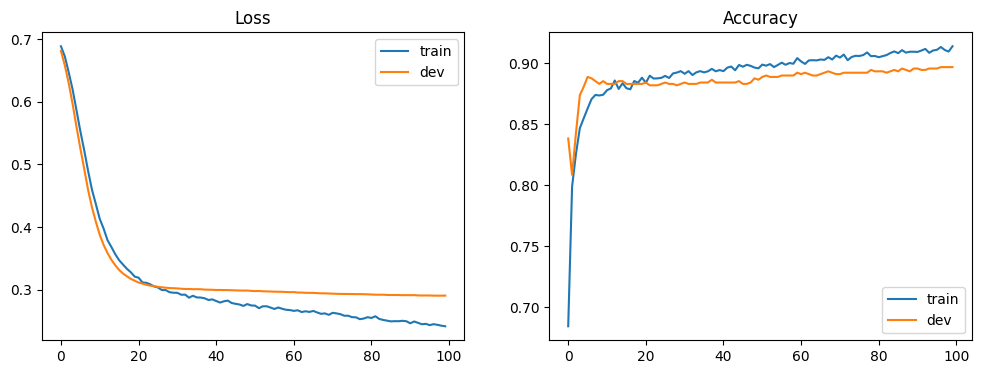

Evaluación final en test:
57/57 - 0s - 3ms/step - accuracy: 0.9072 - loss: 0.2452
[0.2452380359172821, 0.9071938395500183]


In [66]:
# Ejemplo: reentrenar con una configuración elegida (ajústala según resultados de la búsqueda)
best_cfg = results_sorted[0] if len(results_sorted)>0 else {'embedding_dim':100,'hidden_units':128,'dropout':0.3,'l2':1e-4,'lr':5e-4}
print('Usando configuración final:', best_cfg)
final_model = build_mlp(vocab_size, embedding_dim=best_cfg['embedding_dim'], hidden_units=best_cfg['hidden_units'], dropout_rate=best_cfg['dropout'], l2_reg=best_cfg['l2'], learning_rate=best_cfg['lr'])
hist = train_and_plot(final_model, X_train, y_train, X_dev, y_dev, epochs=100, batch_size=64)
print('Evaluación final en test:')
print(final_model.evaluate(X_test, y_test, verbose=2))